##**Experiment Number:- 05**

Build a logistic regresion classifier for spam detection, evaluating with precision-recall curves.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
import wordcloud

#### Load datset

In [63]:
df = pd.read_csv('spam.csv', encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [64]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [65]:
df = df.iloc[:,:2]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [66]:
ham_data = df[df['label']=='ham']
spam_data = df[df['label']=='spam']
ham_data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...


In [67]:
def show_wordcloud(data_spam_or_ham, title):
    text = ' '.join(data_spam_or_ham['message'].astype(str).tolist())
    stopwords = set(wordcloud.STOPWORDS)

    fig_wordcloud = wordcloud.WordCloud(stopwords=stopwords,background_color='lightgrey',
                    colormap='winter', width=800, height=600).generate(text)

    plt.figure(figsize=(10,7), frameon=True)
    plt.imshow(fig_wordcloud)
    plt.axis('off')
    plt.title(title, fontsize=20 )
    plt.show()

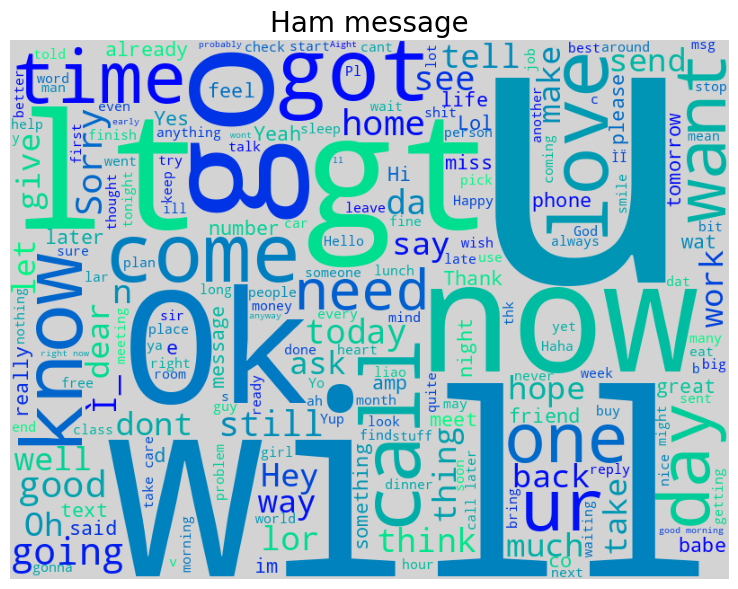

In [68]:
show_wordcloud(ham_data,"Ham message")

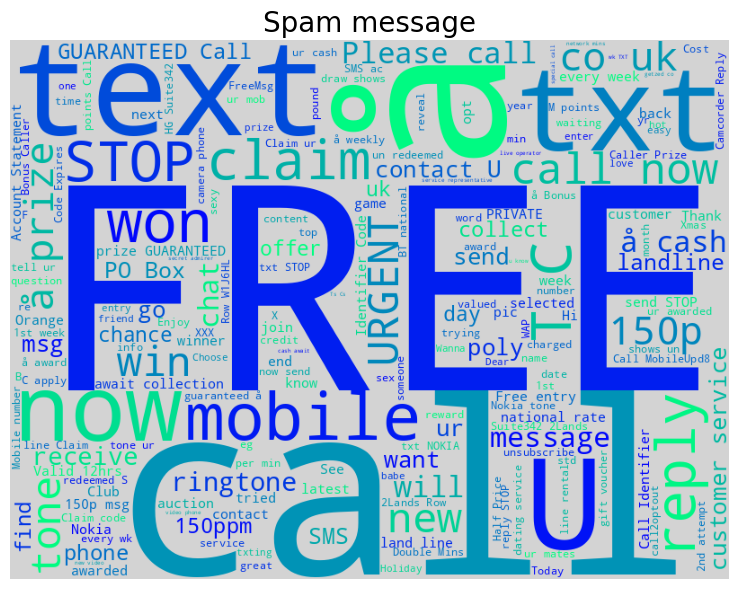

In [69]:
show_wordcloud(spam_data,"Spam message")

#### Encode labels (ham: 0, spam : 1)

In [70]:
df['label'] = df['label'].map({'ham':0, 'spam':1})
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


#### label

In [71]:
df['label'].value_counts()

,count
label,
0,4825
1,747


#### Count Plot of Classes

/tmp/ipython-input-2511826706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fg = sns.countplot(x=df['label'], palette=cols)


Text(0, 0.5, 'Number of Data points')

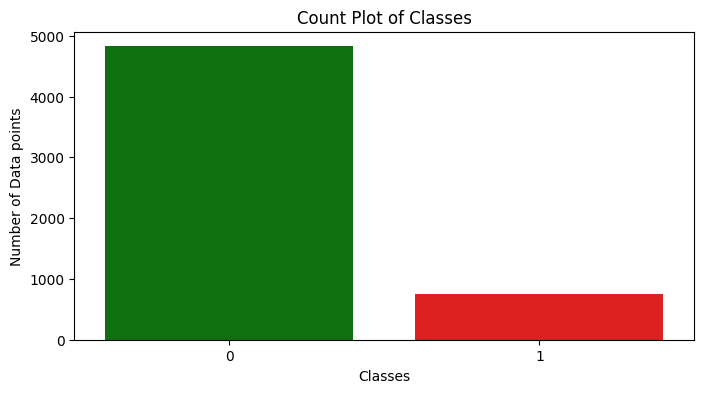

In [72]:
cols= ["green", "red"]
plt.figure(figsize=(8, 4))
fg = sns.countplot(x=df['label'], palette=cols)
fg.set_title("Count Plot of Classes")
fg.set_xlabel("Classes")
fg.set_ylabel("Number of Data points")

#### Split the dataset into Train/Test

In [73]:
X_train,X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size= 0.2, random_state= 42)


#### Text vectorization

In [74]:
vectorize = TfidfVectorizer(stop_words='english',max_features= 5000, lowercase=True)
X_train_vec = vectorize.fit_transform(X_train)
X_test_vec = vectorize.transform(X_test)

#### Train the Logistic Regression

In [75]:
model = LogisticRegression()
model.fit(X_train_vec,y_train)

LogisticRegression()

#### Predictions

In [76]:
y_pred = model.predict(X_test_vec)

#### Accuracy

In [77]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.957847533632287


#### Classification report

In [78]:
print(f"Classification Report: {classification_report(y_test, y_pred)}")

Classification Report:               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.97      0.71      0.82       150

    accuracy                           0.96      1115
   macro avg       0.96      0.85      0.90      1115
weighted avg       0.96      0.96      0.95      1115



#### Confusion matrix

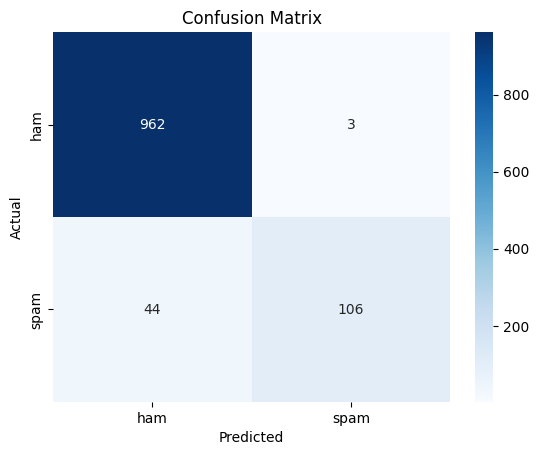

In [79]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot= True, fmt='d', cmap = 'Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### **Check model on  dataset**

In [80]:
message_input = [""]
message_vec = vectorize.transform(message_input)
y_pred = model.predict(message_vec)
print(y_pred)
if y_pred[0] == 1:
  print("SPAM")
else:
  print("NOT SPAM")

[0]
NOT SPAM


In [81]:
y_scores = model.predict_proba(X_test_vec)[:, 1]

In [82]:
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

In [83]:
pr_auc = auc(recall, precision)

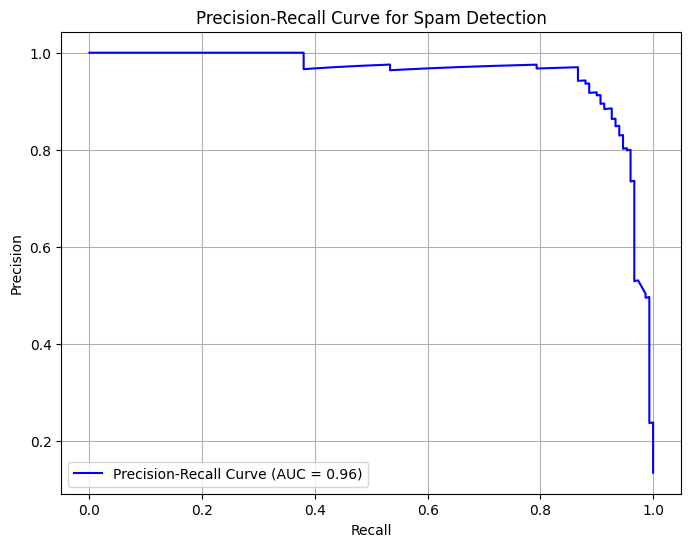

In [84]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', label=f'Precision-Recall Curve (AUC = {pr_auc:.2f})')

# Add labels and title
plt.title('Precision-Recall Curve for Spam Detection')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.legend(loc='lower left')

# Display the plot
plt.show()
